<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da14_movielens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Movielens 데이터 분석

# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비

In [2]:
# 데이터 파일들의 github 경로
movies_file = 'https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/datasets/movielens/movies.dat'
ratings_file = 'https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/datasets/movielens/ratings.dat'
users_file = 'https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/datasets/movielens/users.dat'

In [3]:
# 각각의 데이터프레임에서 사용할 컬럼 이름들
movies_columns = ['movie_id', 'title', 'genres']
ratings_columns = ['user_id', 'movie_id', 'rating', 'timestamp']
users_columns = ['user_id', 'gender', 'age', 'occupation', 'zip_code']

## 데이터프레임 생성

*   movies
*   ratings
*   users
*   데이터프레임 합치기(merge)
    *   ratings와 movies를 merge(inner join)
    *   위의 결과와 users를 merge(inner join)

### movies 데이터프레임

In [4]:
movies = pd.read_csv(movies_file, names=movies_columns, sep='::', engine='python')

In [5]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  3883 non-null   int64 
 1   title     3883 non-null   object
 2   genres    3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


### ratings 데이터프레임

In [7]:
ratings = pd.read_csv(ratings_file, names=ratings_columns, sep='::', engine='python')

In [8]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [9]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [10]:
# timestamp(정수) 컬럼 --> 날짜/시간(datetime) 타입으로 변환.
pd.to_datetime(ratings.timestamp, unit='s')  # unit: 's', 'ms', 'ns'

,timestamp
0,2000-12-31 22:12:40
1,2000-12-31 22:35:09
2,2000-12-31 22:32:48
3,2000-12-31 22:04:35
4,2001-01-06 23:38:11
...,...
1000204,2000-04-26 02:35:41
1000205,2000-04-25 23:21:27
1000206,2000-04-25 23:19:06
1000207,2000-04-26 02:20:48


### users 데이터프레임

In [11]:
users = pd.read_csv(users_file, names=users_columns, sep='::', engine='python')

In [12]:
users.head()

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [13]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     6040 non-null   int64 
 1   gender      6040 non-null   object
 2   age         6040 non-null   int64 
 3   occupation  6040 non-null   int64 
 4   zip_code    6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


## DataFrame merge

### ratings와 movies를 inner join

In [14]:
df = pd.merge(left=ratings, right=movies)

In [16]:
df.head(n=7)

,user_id,movie_id,rating,timestamp,title,genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy
5,1,1197,3,978302268,"Princess Bride, The (1987)",Action|Adventure|Comedy|Romance
6,1,1287,5,978302039,Ben-Hur (1959),Action|Adventure|Drama


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   user_id    1000209 non-null  int64 
 1   movie_id   1000209 non-null  int64 
 2   rating     1000209 non-null  int64 
 3   timestamp  1000209 non-null  int64 
 4   title      1000209 non-null  object
 5   genres     1000209 non-null  object
dtypes: int64(4), object(2)
memory usage: 45.8+ MB


### df와 users를 inner join

In [18]:
df = pd.merge(left=df, right=users)

In [19]:
df.head(n=7)

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067
5,1,1197,3,978302268,"Princess Bride, The (1987)",Action|Adventure|Comedy|Romance,F,1,10,48067
6,1,1287,5,978302039,Ben-Hur (1959),Action|Adventure|Drama,F,1,10,48067


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   user_id     1000209 non-null  int64 
 1   movie_id    1000209 non-null  int64 
 2   rating      1000209 non-null  int64 
 3   timestamp   1000209 non-null  int64 
 4   title       1000209 non-null  object
 5   genres      1000209 non-null  object
 6   gender      1000209 non-null  object
 7   age         1000209 non-null  int64 
 8   occupation  1000209 non-null  int64 
 9   zip_code    1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


# 데이터 탐색

*   카테고리 변수 탐색
    *   성별(gender) 빈도수
    *   연령대(age) 빈도수
    *   직업군(occupation) 빈도수
    *   별점(rating) 빈도수

## 성별 분석

In [23]:
df.gender.value_counts()

,count
gender,
M,753769
F,246440


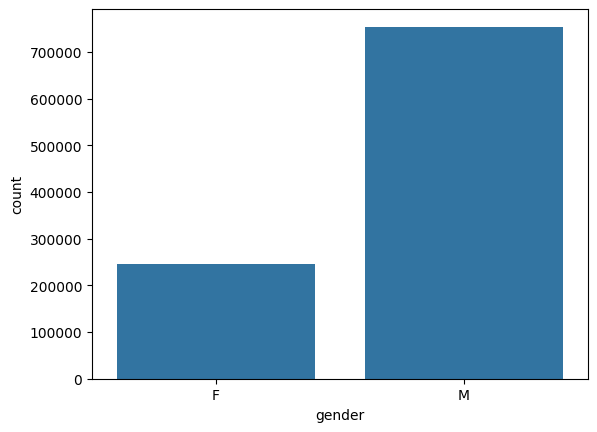

In [24]:
sns.countplot(data=df, x='gender')
plt.show()

## 연령대 분석

In [27]:
df.age.value_counts()

,count
age,
25,395556
35,199003
18,183536
45,83633
50,72490
56,38780
1,27211


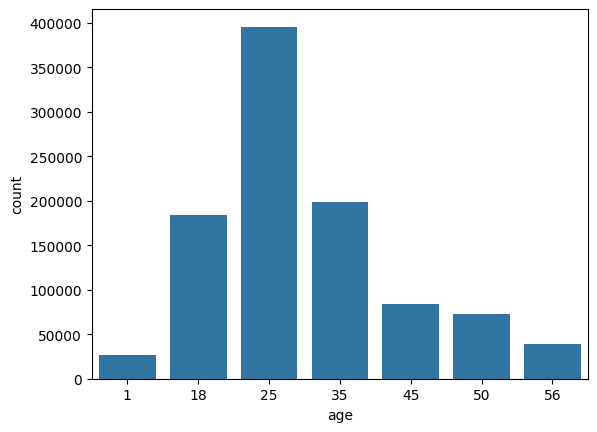

In [28]:
sns.countplot(data=df, x='age')
plt.show()

## 직업군 분석

In [31]:
df.occupation.value_counts()

,count
occupation,
4,131032
0,130499
7,105425
1,85351
17,72816
20,60397
12,57214
2,50068
14,49109


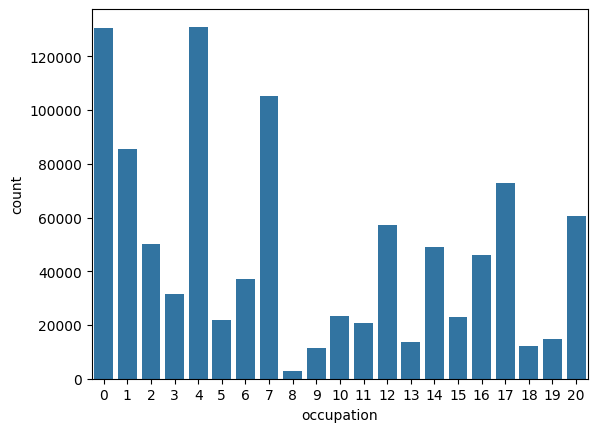

In [32]:
sns.countplot(data=df, x='occupation')
plt.show()

## 별점 분석

In [35]:
df.rating.value_counts()

,count
rating,
4,348971
3,261197
5,226310
2,107557
1,56174


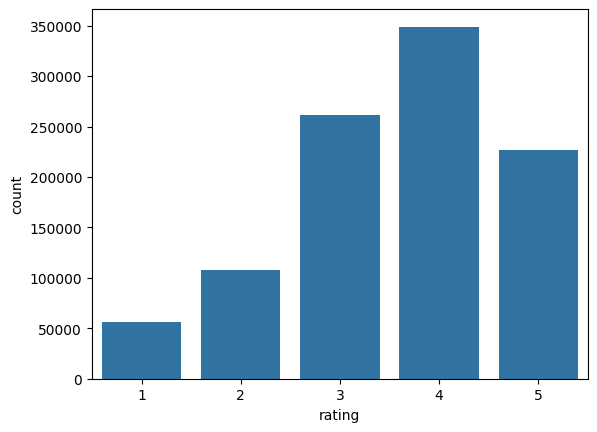

In [36]:
sns.countplot(data=df, x='rating')
plt.show()

# 데이터 분석

## 별점 평균 상위 10개/하위 10개 영화 제목

영화 제목별 별점 평균 계산, 정렬

In [37]:
by_title = df.groupby(by='title').rating.mean()
by_title

,rating
title,
"$1,000,000 Duck (1971)",3.027027
'Night Mother (1986),3.371429
'Til There Was You (1997),2.692308
"'burbs, The (1989)",2.910891
...And Justice for All (1979),3.713568
...,...
"Zed & Two Noughts, A (1985)",3.413793
Zero Effect (1998),3.750831
Zero Kelvin (Kjærlighetens kjøtere) (1995),3.500000


In [40]:
# 별점 평균 상위 10개 영화
by_title.sort_values(ascending=False).head(n=10)

,rating
title,
Lured (1947),5.0
Ulysses (Ulisse) (1954),5.0
"Baby, The (1973)",5.0
Follow the Bitch (1998),5.0
Schlafes Bruder (Brother of Sleep) (1995),5.0
Bittersweet Motel (2000),5.0
Song of Freedom (1936),5.0
"Gate of Heavenly Peace, The (1995)",5.0
One Little Indian (1973),5.0


In [42]:
# 별점 평균 하위 10개 영화 제목
by_title.sort_values().head(n=10)

,rating
title,
Windows (1980),1.0
Wirey Spindell (1999),1.0
Torso (Corpi Presentano Tracce di Violenza Carnale) (1973),1.0
Kestrel's Eye (Falkens öga) (1998),1.0
Terror in a Texas Town (1958),1.0
Santa with Muscles (1996),1.0
"Silence of the Palace, The (Saimt el Qusur) (1994)",1.0
"Low Life, The (1994)",1.0
Even Dwarfs Started Small (Auch Zwerge haben klein angefangen) (1971),1.0


In [45]:
df[df.title == 'Lured (1947)']

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
879590,5313,3656,5,960920392,Lured (1947),Crime,M,56,0,55406


In [46]:
df[df.title == 'Windows (1980)']

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
287002,1713,684,1,974705435,Windows (1980),Drama,M,25,0,47421


별점 리뷰 건수가 1~2개 밖에 없는 영화들의 별점 평균은 큰 의미가 없음.

일정 개수 이상의 별점 리뷰가 있는 영화들을 선택해서 별점 평균을 분석하는 것이 의미가 있음.

In [50]:
# 영화 제목 빈도수
title_counts = df.title.value_counts()
title_counts

,count
title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
...,...
Aiqing wansui (1994),1
Broken Vessels (1998),1
White Boys (1999),1


In [51]:
title_counts.head(n=10)

,count
title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
Saving Private Ryan (1998),2653
Terminator 2: Judgment Day (1991),2649
"Matrix, The (1999)",2590
Back to the Future (1985),2583


In [52]:
title_counts.describe()

,count
count,3706.000000
mean,269.889099
std,384.047838
min,1.000000
25%,33.000000
50%,123.500000
75%,350.000000
max,3428.000000


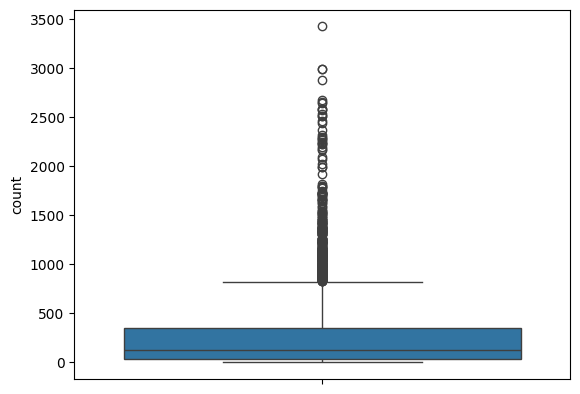

In [53]:
sns.boxplot(data=title_counts)
plt.show()

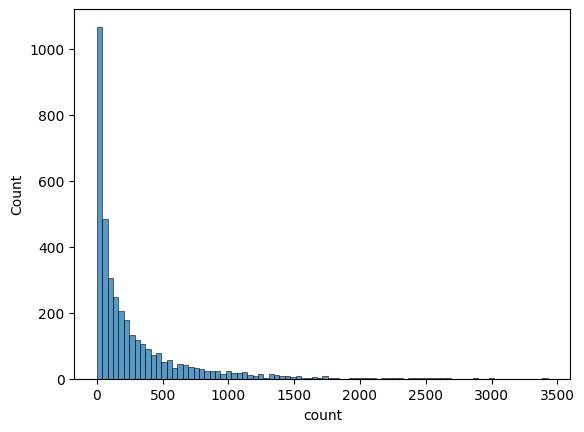

In [54]:
sns.histplot(data=title_counts)
plt.show()

## 별점 리뷰 횟수가 120회 이상인 영화들을 선택해서 분석